In [1]:
import pygimli as pg
import pygimli.meshtools as mt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cartopy.crs as ccrs
from scipy.interpolate import griddata, RegularGridInterpolator
from scipy.spatial import KDTree
import pickle
import gepy
from scipy.ndimage import gaussian_filter


In [2]:
k0 = 2.7 # ((sediment))
k1 = 2.7 # crust
k2 = 3.0 # UM
k3 = 4.0 # LM #XX

RHP = 0.000000705

km = 1000 # multiplicative factor for m-km conversion

input_path = 'output/data_input.pickle'
input_RHP_path = 'output/RHP_data_input.pickle'

area_coord_s = [-9.8e5,-9e5,-12.7e5, -13.5e5] # horizontal extent of the model
interface_resolutions = [100,100, 20, 10] # number of pixels in each interface # ACHTUNG HIER SEDIMENTS AUCH


run_name = "LAB_MESH"
data_projection = ccrs.NorthPolarStereo()
plot_stuff = False

buffer_pixel = 1 # number of pixels of the roughest dataset as buffer
border_2 = 10
labels = ["Topography","sediment","Moho","LAB"]
markers = [4, 5, 6, 7] # 4: topography, 5: sediment, 6: moho, 7: lab


#mesh_path = "C:\Users\User\Documents\HIWI\GHF_forward_modelling_FRANKENSTEIN\output\LAB_MESH_mesh.vtk"
mesh_path = "output/LAB_MESH_mesh.vtk"

In [3]:
# area_coord_s = [0, 3000000.0/2 , 0, 3000000.0/2 ]
# area_coord_s = [0, 3000000.0/2 , 3000000.0/2, 0 ] # XX huh?!

# data_projection = ccrs.SouthPolarStereo()
# input_path = "data_input_ANT.pickle"
# input_RHP_path = "RHP_data_input_ANT.pickle"

In [4]:
with open(input_path, 'rb') as handle:
    data_calc,data_resolution = pickle.load(handle)
#data_calc = [[data_calc[0][0],data_calc[0][1],data_calc[0][2]],[data_calc[1][0],data_calc[1][1],np.ones(np.shape(data_calc[1][1])) * 1],[data_calc[2][0],data_calc[2][1],np.ones(np.shape(data_calc[2][2])) * 50000],[data_calc[3][0],data_calc[3][1],data_calc[3][2]]]
#data_calc = [[data_calc[0][0],data_calc[0][1],data_calc[0][2]],[data_calc[1][0],data_calc[1][1],np.ones(np.shape(data_calc[1][1])) * 1],[data_calc[2][0],data_calc[2][1],np.ones(np.shape(data_calc[2][2])) * 50000],[data_calc[3][0],data_calc[3][1],np.ones(np.shape(data_calc[3][2])) * 200000]]
#data_calc = [[data_calc[0][0],data_calc[0][1],np.ones(np.shape(data_calc[0][2])) * 100],[data_calc[1][0],data_calc[1][1],np.ones(np.shape(data_calc[1][2])) * 1],[data_calc[2][0],data_calc[2][1],data_calc[2][2]],[data_calc[3][0],data_calc[3][1],data_calc[3][2]]]

data_calc[2][2] = data_calc[2][2] *-1
data_calc[3][2] = data_calc[3][2] *-1

X, Y = data_calc[0][0],data_calc[0][1]
# Normalize X and Y to [0, 1]
# X_norm = (X - X.min()) / (X.max() - X.min())
# Y_norm = (Y - Y.min()) / (Y.max() - Y.min())
# bilinear_data = (1 - X_norm) * (1 - Y_norm)

#data_calc[3][2] = bilinear_data * 10000-200000



width = abs(area_coord_s[0]-area_coord_s[1])
height = abs(area_coord_s[2]-area_coord_s[3])
res_topo,res_moho,res_lab = (width/interface_resolutions[0],width/interface_resolutions[1],width/interface_resolutions[2])

resolutions = [width/i_r for i_r in interface_resolutions]

print(width,height)
print(resolutions)

buffer = max(resolutions) *buffer_pixel


80000.0 80000.0
[800.0, 800.0, 4000.0, 8000.0]


In [5]:
def plot_data(x_plot,y_plot,c_plot,cmap="viridis",vmin=-1e9, vmax=1e9,cbar_label="", show = False):
    """
    Plots data on a Cartopy map projection.
    Parameters:
    x_plot : array-like
        X-coordinates of the data points.
    y_plot : array-like
        Y-coordinates of the data points.
    c_plot : array-like
        Values to be plotted, corresponding to the coordinates.
    cmap : str, optional
        Colormap to use for the plot (default is "viridis").
    vmin : float, optional
        Minimum value for color scaling (default is np.nanmin(c_plot)).
    vmax : float, optional
        Maximum value for color scaling (default is np.nanmax(c_plot)).
    cbar_label : str, optional
        Label for the colorbar
    show : bool, optional
        If True, displays the plot immediately (default is False).
    Returns:
    ax : matplotlib.axes.Axes
        The axes object containing the plot.
    """
    if vmin==-1e9:
        vmin=np.nanmin(c_plot)
    if vmax==1e9:
        vmax=np.nanmax(c_plot)
    plt.figure()
    ax = plt.axes(projection=data_projection)
    sc = ax.pcolormesh(x_plot,y_plot,c_plot, cmap=cmap,vmin=vmin,vmax=vmax)
    ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, alpha=0.5, rotate_labels = False)
    ax.coastlines(resolution='50m',linewidth=0.5)
    plt.colorbar(sc,label=cbar_label)
    if show:
        plt.show()
    return ax

In [6]:

if plot_stuff:
    for i in range(len(data_calc)):
        ax = plot_data(data_calc[i][0],data_calc[i][1],data_calc[i][2],cmap='YlGnBu_r',cbar_label=labels[i])
        rect = patches.Rectangle((area_coord_s[0], area_coord_s[3]), area_coord_s[1]-area_coord_s[0], area_coord_s[2]-area_coord_s[3], linewidth=1, edgecolor='r', facecolor='none')
        ax.add_patch(rect)



In [7]:
def in_area_s_ANT(acs,x,y,g):
    '''
    Limit the size of the originial dataset to make interpolation easier

    Parameters
    ----------
    acs : research area coordinates
    x : xi of grid
    y : yi of grid
    g : data grid

    Returns
    -------
    x_s : smaller xi of grid
    y_s : smaller yi of grid
    grid_s : smaller data grid
    '''
    #buffer = 5000

    # Apply buffer to coordinates
    xmin, xmax, ymax,ymin  = acs

    xmin -= buffer
    xmax += buffer
    ymin -= buffer
    ymax += buffer

    #x = np.unique(x)
    #y = np.unique(y)
    x = x[0,:] # maybe differnt from unique??
    y = y[:,0]
    # Select indices within the buffered area
    x_mask = (x >= xmin) & (x <= xmax)
    y_mask = (y >= ymin) & (y <= ymax)
    
    x_s = x[x_mask]
    y_s = y[y_mask]
    
    # Apply masks to the data grid
    grid_s = g[np.ix_(y_mask, x_mask)]
    
    return x_s, y_s, grid_s

In [8]:
xi_s, yi_s, grid_s,   xii_s,yii_s,    x_int,y_int,    xi_int,yi_int = [], [], [],    [], [],    [],[],   [],[]


for i in range(len(data_calc)):
    print(labels[i])
    xi_s_tmp, yi_s_tmp, grid_s_tmp = in_area_s_ANT(area_coord_s,data_calc[i][0],data_calc[i][1],data_calc[i][2])
    xi_s.append(xi_s_tmp)
    yi_s.append(yi_s_tmp)
    grid_s.append(grid_s_tmp)

    xii_s_tmp,yii_s_tmp = np.meshgrid(xi_s_tmp,yi_s_tmp)
    xii_s.append(xii_s_tmp)
    yii_s.append(yii_s_tmp)


    x_int_tmp = np.linspace(area_coord_s[0],area_coord_s[1],int(abs((area_coord_s[0]-area_coord_s[1])/resolutions[i])))
    y_int_tmp = np.linspace(area_coord_s[3],area_coord_s[2],int(abs((area_coord_s[3]-area_coord_s[2])/resolutions[i])))
    x_int.append(x_int_tmp)
    y_int.append(y_int_tmp)

    xi_int_tmp,yi_int_tmp = np.meshgrid(x_int_tmp,y_int_tmp)
    xi_int.append(xi_int_tmp)
    yi_int.append(yi_int_tmp)


Topography
sediment
Moho
LAB


In [9]:
if plot_stuff:
    for i in range(len(data_calc)):
        plot_data(xi_s[i],yi_s[i],grid_s[i],cmap='YlGnBu_r',cbar_label=labels[i])


In [10]:
grid = []
grid_for_topo = []

for i in range(len(data_calc)):
    interp = RegularGridInterpolator((np.unique(xi_s[i]),np.unique(yi_s[i])),grid_s[i].T)
    grid_tmp = interp((xi_int[i],yi_int[i]))
    grid_tmp[np.isnan(grid_tmp)] = np.nanmean(grid_tmp) # fill in nans just to be sure

    grid_for_topo.append(interp((xi_int[0],yi_int[0])))

    grid.append(grid_tmp)

In [11]:
if plot_stuff:
    for i in range(len(data_calc)):
        plot_data(xi_int[i],yi_int[i],grid[i],cmap='YlGnBu_r',cbar_label=labels[i])

In [12]:
#%% build the world

# create 3d mesh from the input data

# the +/- 10 are to create a slight buffer around the input data and world edge, there are issues
# in the mesh creation when edges of boundaries touch other boundaries
border = 10
border = buffer # ca 16000m - eine LAB pixelgröße

border = border_2

worldceiling = 10 # in km
worldfloor = -300 # hardcoded for now
start = [(area_coord_s[0]-border)/km,(area_coord_s[2]+border)/km,worldceiling]
end = [(area_coord_s[1]+border)/km,(area_coord_s[3]-border)/km,worldfloor] #https://www.pygimli.org/pygimliapi/_generated/pygimli.meshtools.html#pygimli.meshtools.createWorld
#end = [(area_coord_s[1]+border)/km,(area_coord_s[3]-border)/km,(-np.nanmax(grid[-1])-10)] #https://www.pygimli.org/pygimliapi/_generated/pygimli.meshtools.html#pygimli.meshtools.createWorld

world = mt.createWorld(start=start,end=end, worldMarker=False)


In [13]:
print(np.nanmax(grid[-1]))

-139007.9594042591


In [14]:
surface = []

for i in range(len(data_calc)):
    print("Surface ",labels[i], " with marker ",markers[i])

    mesh_tmp = mt.createMesh2D(x_int[i]/km,y_int[i]/km)
    surface_tmp = mt.createSurface(mesh_tmp)
    surface_tmp = gepy.fix_surface_height(surface_tmp, x_int[i]/km, y_int[i]/km, grid[i]/km) # from here on out - we deal in km
    for boundary in surface_tmp.boundaries():
        boundary.setMarker(markers[i])
    surface.append(surface_tmp)

Surface  Topography  with marker  4
Surface  sediment  with marker  5
Surface  Moho  with marker  6
Surface  LAB  with marker  7


In [15]:
mesh_load = pg.load(mesh_path)

In [19]:
print(mesh_load)

mesh = mesh_load.copy()

print(mesh) #  ich denke dass die boundayr marker nicht exportiert werden

Mesh: Nodes: 73057 Cells: 295647 Boundaries: 628466
Mesh contains data: Marker, T, T_gradient
Mesh: Nodes: 73057 Cells: 295647 Boundaries: 628466
Mesh contains data: Marker, T, T_gradient


In [20]:
print(mesh.findBoundaryByMarker(1))
pg.show(mesh.findBoundaryByMarker(1))

tmp = mesh.findBoundaryByMarker(7)
tmp_load = mesh_load.findBoundaryByMarker(7) #-> emtpy

23/07/25 - 10:12:48 - pyGIMLi - ERROR - None.show(c:\Users\User\anaconda3\envs\pg\Lib\site-packages\pygimli\viewer\showmesh.py:159)
Can't interprete obj: <pgcore._pygimli_.stdVectorBounds object at 0x00000241C17C78C0> to show.


In [21]:
try:
    #p=1
    1/0
    with open(mesh_path) as f:
        print(f.read())
    mesh = pg.load(mesh_path)
except:
    print("Creating mesh...")
    geometry = world
    for surf in surface:
        geometry += surf
    mesh = mt.createMesh(geometry,quality=34)#34,area=2.5)

Creating mesh...


In [22]:
#surface_topo,surface_sed = gepy.create_sed_interface(x_int_t, y_int_t, grid_topo, grid_sed) # die km werden in gepy noch berücksichtigt
# ^^ triangles dont seem to work at this resolution... :(
# vv we'll have to work with squares then
# mesh_topo = mt.createMesh2D(x_int_t/km,y_int_t/km)
# surface_topo  = mt.createSurface(mesh_topo)
# surface_topo = gepy.fix_surface_height(surface_topo, x_int_t/km, y_int_t/km, grid_topo/km)

# for boundary in surface_topo.boundaries():
#     boundary.setMarker(4)



23/07/25 - 10:14:51 - pyGIMLi - WARNING - Given data fits neither cell count nor node count:
23/07/25 - 10:14:51 - pyGIMLi - WARNING - 628466 vs. 0 vs. 68927


Widget(value='<iframe src="http://localhost:51643/index.html?ui=P_0x241fd6560d0_0&reconnect=auto" class="pyvis…

Widget(value='<iframe src="http://localhost:51643/index.html?ui=P_0x243405181d0_1&reconnect=auto" class="pyvis…

Widget(value='<iframe src="http://localhost:51643/index.html?ui=P_0x24340518e10_2&reconnect=auto" class="pyvis…

Widget(value='<iframe src="http://localhost:51643/index.html?ui=P_0x243412234d0_3&reconnect=auto" class="pyvis…

C:\Users\User\AppData\Local\Temp\ipykernel_9584\3522114716.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


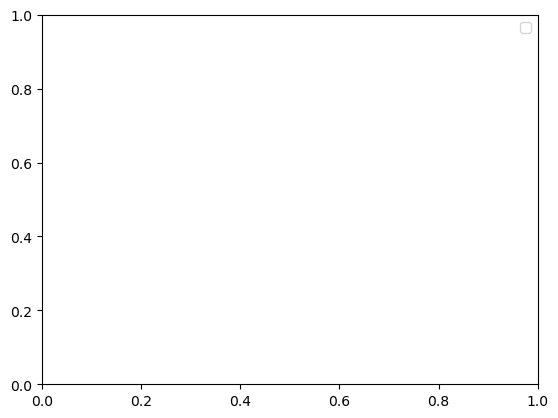

Mesh: Nodes: 73057 Cells: 295647 Boundaries: 628466


Widget(value='<iframe src="http://localhost:51643/index.html?ui=P_0x2434110c050_4&reconnect=auto" class="pyvis…

23/07/25 - 10:18:35 - wslink.protocol - ERROR - Exception raised
23/07/25 - 10:18:35 - wslink.protocol - ERROR - KeyError('c5a3dffa7aef5106405502dd323b7483_74344i')
23/07/25 - 10:18:35 - wslink.protocol - ERROR - Traceback (most recent call last):
  File "c:\Users\User\anaconda3\envs\pg\Lib\site-packages\wslink\protocol.py", line 313, in onCompleteMessage
    results = func(*args, **kwargs)
              ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\User\anaconda3\envs\pg\Lib\site-packages\trame_vtk\modules\vtk\protocols\local_rendering.py", line 33, in get_array
    self.context.get_cached_data_array(data_hash, binary)
  File "c:\Users\User\anaconda3\envs\pg\Lib\site-packages\trame_vtk\modules\vtk\serializers\synchronization_context.py", line 35, in get_cached_data_array
    cache_obj = self.data_array_cache[p_md5]
                ~~~~~~~~~~~~~~~~~~~~~^^^^^^^
KeyError: 'c5a3dffa7aef5106405502dd323b7483_74344i'



In [ ]:
if plot_stuff or True:
    pg.show(mesh, label='Mesh', markers=True,  alpha=0.7)
    pg.show(surface[0], label=labels[0], markers=True,  alpha=1)
    pg.show(surface[2], label=labels[2], markers=True,  alpha=1)
    pg.show(surface[3], label=labels[3], markers=True,  alpha=1)
    #pg.show(surface_topo, showMesh=True, alpha=1, data=grid_topo.flatten())
    plt.legend()
    plt.show()


    grid_topo_flat = grid[0].flatten()
    grid_moho_flat = grid[2].flatten()
    grid_lab_flat = grid[3].flatten()

    combined_data = np.concatenate([[np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan],grid_topo_flat, grid_moho_flat, grid_lab_flat])
    #pg.show(geometry, showMesh=True, alpha=0.7, data=combined_data) #disabled with loaded mesh

    print(mesh)
    pg.show(mesh,showMesh=True,alpha=0.7)

    #print(geometry)#disabled with loaded mesh
    #pg.show(geometry,showMesh=True,alpha=0.7)#disabled with loaded mesh


In [24]:
'''
Radiogenic Heat Production:
'''

with open(input_RHP_path, 'rb') as handle:
    [xi_A,yi_A,grid_A] = pickle.load(handle)
#    grid_A = np.ones(np.shape(grid_A))*3.1863201703538226e-07 *km*km*km
    #grid_A = np.ones(np.shape(grid_A))*3.315482211738545e-07 *km*km*km #  in area

#A = np.ones(np.shape(data_calc[0][2]))*RHP
#xi_topo,yi_topo = data_calc[0][0], data_calc[0][1] # maybe still needed for debugging
#xi_smos,yi_smos = data_calc[0][0], data_calc[0][1]


#A = np.ones(np.shape(A))*RHP



A = grid_A /km /km /km
#xi_smos,yi_smos = xi_A,yi_A


dx = np.abs(xi_A[0,1] - xi_A[0,0])  # x spacing (horizontal)
dy = np.abs(yi_A[1,0] - yi_A[0,0])  # y spacing (vertical)

# Expand bounds by one pixel in each direction
expanded_coords = [
    area_coord_s[0] - 5*dx,  # xmin - 1 pixel
    area_coord_s[1] + 5*dx,  # xmax + 1 pixel
    area_coord_s[2] - 5*dy,  # ymin - 1 pixel
    area_coord_s[3] + 5*dy   # ymax + 1 pixel
]

#xi_smos_s, yi_smos_s, A_s = gepy.in_area_s(area_coord_s,xi_A,yi_A,A)
xi_smos_s, yi_smos_s, A_s = in_area_s_ANT(expanded_coords,xi_A,yi_A,A)
xii_smos_s,yii_smos_s   = np.meshgrid(xi_smos_s,yi_smos_s)
    
res_HP = width/8
    
x_int_HP,y_int_HP = np.arange(area_coord_s[0],area_coord_s[1]+res_HP,res_HP),  np.arange(area_coord_s[3],area_coord_s[2]+res_HP,res_HP)
xi_int_HP,yi_int_HP = np.meshgrid(x_int_HP,y_int_HP)

grid_A  = griddata((xii_smos_s.flatten(), yii_smos_s.flatten()), np.transpose(A_s).flatten(), (xi_int_HP,yi_int_HP),fill_value=np.nan)

#grid_A = np.ones(np.shape(grid_A))*np.nanmean(grid_A) /km /km /km #!!



# Flatten original grid and values
x_coords = xii_smos_s.flatten()
y_coords = yii_smos_s.flatten()
values = A_s.flatten()
#values = (np.ones(np.shape(A_s))*np.nanmean(A_s) /km /km /km).flatten() #!!


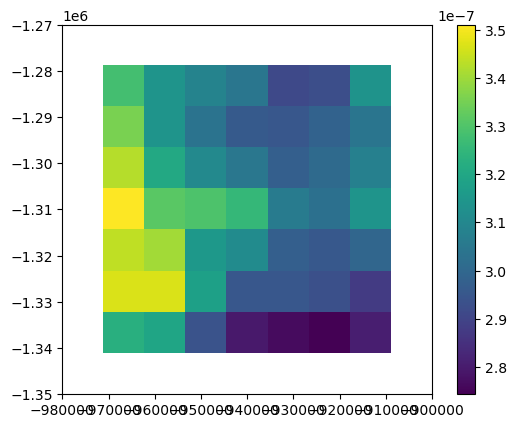

In [25]:
plt.imshow(grid_A, extent=[np.min(xi_int[0]), np.max(xi_int[0]), np.min(yi_int[0]), np.max(yi_int[0])], cmap="viridis")#, norm=divnorm)
plt.colorbar()

In [26]:
# import numpy as np
# from scipy import ndimage

# # grid_A is your 2D array with NaNs around the border
# nan_mask = np.isnan(grid_A)

# # Get indices of nearest non-NaN cells for each NaN
# # 1. Create mask of valid entries
# valid_mask = ~nan_mask

# # 2. Get nearest-neighbor indices for each element
# # This returns arrays of indices pointing to the nearest valid entry
# idx = ndimage.distance_transform_edt(nan_mask,
#                                      return_distances=False,
#                                      return_indices=True)

# # 3. Use those indices to fill the NaNs from the nearest non-NaN values
# grid_filled = grid_A.copy()
# grid_filled[nan_mask] = grid_A[tuple(idx[:, nan_mask])]


# plt.imshow(grid_filled,
#            extent=[np.min(xi_int_t), np.max(xi_int_t),
#                    np.min(yi_int_t), np.max(yi_int_t)],
#            cmap="viridis")


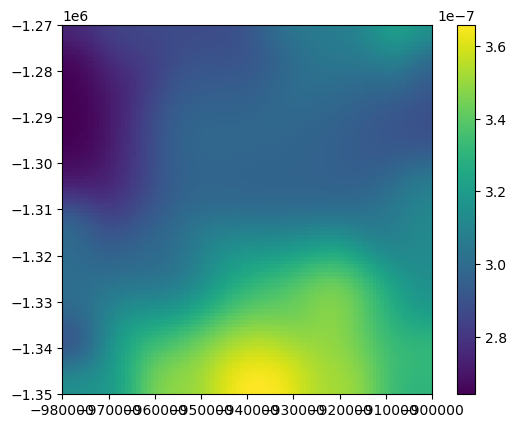

In [27]:


# Define new grid
#xi_int_t, yi_int_t = np.meshgrid(x_int_t, y_int_t)

# Perform cubic interpolation
z_interp = griddata((x_coords, y_coords), values, (xi_int[0], yi_int[0]), method='linear')

# Fill NaN values with nearest neighbor interpolation
z_interp_nearest = griddata((x_coords, y_coords), values, (xi_int[0], yi_int[0]), method='nearest')

# Replace NaNs in cubic with nearest values
z_interp[np.isnan(z_interp)] = z_interp_nearest[np.isnan(z_interp)]

#grid_A = z_interp
# Apply Gaussian smoothing to blend edges
z_interp_smooth = gaussian_filter(z_interp, sigma=5) 
grid_A = np.fliplr(np.flipud(z_interp_smooth))

grid_A_for_topo = grid_A

plt.imshow(grid_A_for_topo, extent=[np.min(xi_int[0]), np.max(xi_int[0]), np.min(yi_int[0]), np.max(yi_int[0])], cmap="viridis")#, norm=divnorm)
plt.colorbar()

In [28]:
tree, grid_xy = [], []

for i in range(len(data_calc)):
    grid_xy_tmp = np.array(list(zip(xi_int[i].flatten()/km,yi_int[i].flatten()/km)))
    tree_tmp = KDTree(grid_xy_tmp)
    grid_xy.append(grid_xy_tmp)
    tree.append(tree_tmp)

force = np.zeros(mesh.nodeCount())

In [29]:

for i, node in enumerate(mesh.nodes()):  # not yet fully vectorized, but works
    #print(i)
    x,y,z = node.pos()
    z_topo = gepy.compare_to_plane(x,y,grid[0],grid_xy[0],tree[0])
    #z_sed = gepy.compare_to_plane(x,y,(grid_topo-grid_sed),grid_xy_ts,tree_ts)
    z_moho = gepy.compare_to_plane(x,y,grid[2],grid_xy[2],tree[2])
    #z_lab = gepy.compare_to_plane(x,y,-grid_lab,grid_xy_l,tree_l)
    
    idx_A,idy_A = np.argmin(np.abs(x_int[0]/km-x)),np.argmin(np.abs(y_int[0]/km-y))
    
    #if z >= z_moho and z <= z_sed:
    if z >= z_moho and z <= z_topo:
        force[i] = grid_A_for_topo[idy_A,idx_A]
        #force[i] = RHP
        #force[i] = np.nanmean(grid_A_for_topo)
    else:
        force[i] = 0

c:\Users\User\Documents\HIWI\GHF_forward_modelling_FRANKENSTEIN\gepy.py:215: RuntimeWarning: divide by zero encountered in scalar divide
  F = (-x*norm[0] - y*norm[1] - D)/norm[2]
c:\Users\User\Documents\HIWI\GHF_forward_modelling_FRANKENSTEIN\gepy.py:211: RuntimeWarning: invalid value encountered in divide
  norm = cross/(np.sqrt(cross[0]**2+cross[1]**2+cross[2]**2))


In [30]:

    
# apply correct marker to the cells
for i,cell in enumerate(mesh.cells()):
    center = cell.center()
    x, y, z = center.x(), center.y(), center.z()
    
    # z_topo = gepy.compare_to_plane(x,y,grid_topo,grid_xy_ts,tree_ts)
    # z_sed = gepy.compare_to_plane(x,y,(grid_topo-grid_sed),grid_xy_ts,tree_ts)
    # z_moho = gepy.compare_to_plane(x,y,-grid_moho,grid_xy_m,tree_m)
    # z_lab = gepy.compare_to_plane(x,y,-grid_lab,grid_xy_l,tree_l)
    z_interface = []
    for j in range(len(data_calc)):
        z_interface.append(gepy.compare_to_plane(x,y,grid[j],grid_xy[j],tree[j]))
    # z_topo = gepy.compare_to_plane(x,y,grid_topo,grid_xy_ts,tree_ts)
    # #z_sed = gepy.compare_to_plane(x,y,(grid_topo-grid_sed),grid_xy_ts,tree_ts)
    # z_moho = gepy.compare_to_plane(x,y,grid_moho,grid_xy_m,tree_m)
    # z_lab = gepy.compare_to_plane(x,y,grid_lab,grid_xy_l,tree_l)
    

    if z < z_interface[0] and z >= z_interface[2]:
        cell.setMarker(4) # XX war mal 5
    #if z < z_sed: # XX TODO SEDIMENT
    #    cell.setMarker(5)
    elif z < z_interface[2] and z >= z_interface[3]:
        cell.setMarker(6)
    elif z < z_interface[3]:
        cell.setMarker(7)

pg.show(mesh,showMesh=True,alpha=0.7)

Widget(value='<iframe src="http://localhost:51643/index.html?ui=P_0x24341094910_5&reconnect=auto" class="pyvis…

(<pyvista.plotting.plotter.Plotter at 0x24341094910>, None)

In [31]:
#%% run calc and get shf



#a_test = {1: 1.0*km, 4: k0*km, 5: k1*km, 6: k2*km, 7: k3*km,        0: 1.0*km, 8: 1.0*km, 9: 1.0*km, 10: 1.0*km}

k_insulate = 0.1 # insulate the top of the model, so that the heat does not escape
a_test = {1: 1.0*km, 4: k0*km, 5: k1*km, 6: k2*km, 7: k3*km,        0: k_insulate*km, 8: k_insulate*km, 9: k_insulate*km, 10: k_insulate*km}
bc_test = {'Dirichlet': {7: 1315, 4: 0}}

T = pg.solver.solveFiniteElements(mesh, a=a_test, f=force*km*km*km, bc=bc_test,verbose=True)#{'Node': Tnode}

T_list = [T[i] for i in range(len(T))]

topcoord = []
for i in range(len(x_int[0])):
    for j in range(len(y_int[0])):
        topcoord.append([x_int[0][i]/km,y_int[0][j]/km,(grid[0][j,i]-5)/km]) # magic number 5 is to avoid problems with the top of the mesh

gradientTop = pg.solver.grad(mesh, T, topcoord)

geology_list = []

shf = np.zeros(len(gradientTop))
for i in range(len(gradientTop)):
    point = pg.RVector3(topcoord[i][0],topcoord[i][1],topcoord[i][2])
    cell = mesh.findCell(point)
    geology = cell.marker()
    geology_list.append(geology)
    if geology == 5:   
        #shf[i] = np.linalg.norm(gradientTop[i,:])*k1
        shf[i] = gradientTop[i,2]*k1*-1
    elif geology == 4:
        #shf[i] = np.linalg.norm(gradientTop[i,:])*k0
        shf[i] = gradientTop[i,2]*k0*-1

shf_3D = np.transpose(np.reshape(shf,(len(x_int[0]),len(y_int[0]))))
gradientTop_rs = np.reshape(gradientTop[:,2],(len(x_int[0]),len(y_int[0])))


Mesh:  Mesh: Nodes: 73057 Cells: 295647 Boundaries: 628466
Assembling time:  18.2802237
Solving time:  2.5231792


In [32]:


mesh["T"] = T

gradient = pg.solver.grad(mesh, T)
#pg.show(mesh,data=gradient[:,2],filter={'clip':{'origin':(1050, 0, 0)},})
mesh["T_gradient"] = gradient

In [33]:
if plot_stuff:
    pg.show(mesh,data=T,showMesh=True, label='Temperature in C', cMap="inferno", alpha=0.7)


In [34]:
def calculate_surface_heat_flow_1D():
    """
    Calculates surface heat flow using fixed temperature boundary conditions.
    
    Parameters:
    grid_topo (numpy array): Topography heights (m)
    grid_lab_for_topo (numpy array): LAB depth (m)
    grid_moho_for_topo (numpy array): Moho depth (m)
    k1 (float): Thermal conductivity of the crust (W/mK)
    k2 (float): Thermal conductivity of the upper mantle (W/mK)
    k3 (float): Thermal conductivity of the lower mantle (W/mK) [not used explicitly if LAB is within UM]
    A_1D (float): Radiogenic heat production in the crust (W/m^3)
    
    Returns:
    numpy array: Surface heat flow values (W/m^2)
    """
    
    # Compute crust and mantle thicknesses
    crust_thickness = grid_for_topo[2] - grid[0]
    mantle_thickness = grid_for_topo[3] - grid_for_topo[2]

    #crust_thickness = grid_moho_for_topo - grid_topo
    #mantle_thickness = grid_lab_for_topo - grid_moho_for_topo
    
    # Fixed boundary conditions
    T_surface = 0.0  # °C
    T_LAB = 1315.0   # °C
    
    # Temperature gradient in the crust (including heat production term)
    q_moho = (A_1D * crust_thickness) + (k1 * (T_LAB - T_surface) / (crust_thickness + mantle_thickness))
    
    # Heat flow through the mantle (assuming conduction only)
    q_surface = q_moho + (A_1D * crust_thickness**2) / 2
    
    return q_surface

min -0.000000 max 46.247417 mean 35.143774


<GeoAxes: >

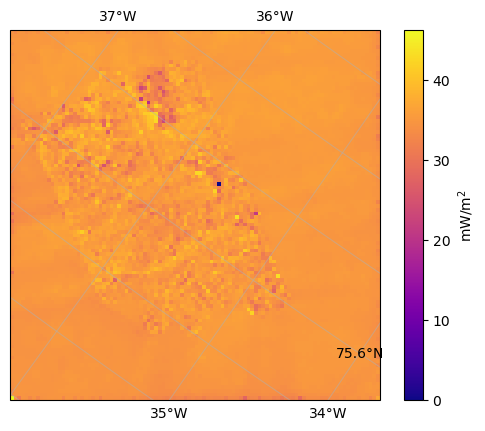

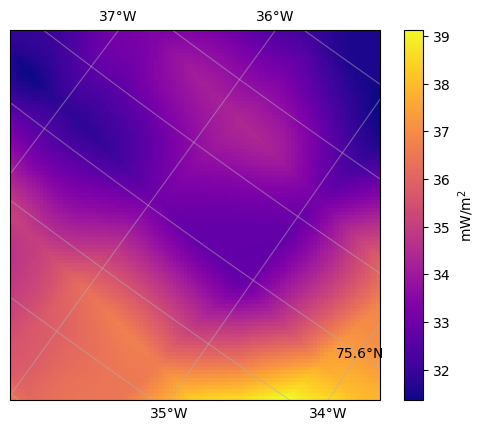

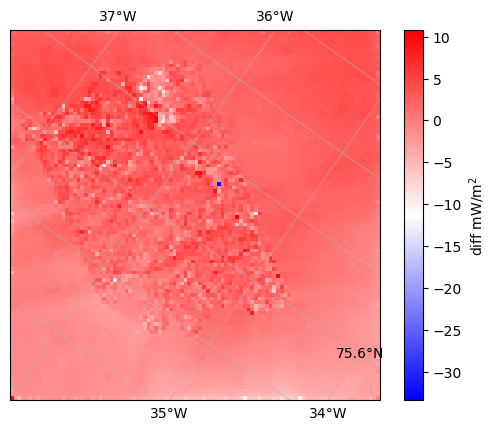

In [35]:
#%% Plot data and compare to 1D result

print("min %f max %f mean %f" %(np.min(shf_3D), np.max(shf_3D), np.mean(shf_3D)))


plot_data(x_int[0], y_int[0], shf_3D, cmap="plasma", cbar_label='mW/m$^2$')

A_1D = RHP
A_1D = grid_A_for_topo # 500x500, der rest is 30x40

# grid_moho_t = grid_moho_for_topo - grid_topo
# grid_lab_t = grid_lab_for_topo - grid_moho_for_topo

grid_moho_t = grid_for_topo[2] - grid[0]
grid_lab_t = grid_for_topo[3] - grid_for_topo[2]
shf_1D = ((1315-0+(A_1D*grid_moho_t*grid_lab_t)/k2+(1/2*A_1D*grid_moho_t**2)/k1) / (grid_lab_t/k2 + grid_moho_t/k1) * km) *-1


#shf_1D = calculate_surface_heat_flow_1D() # doesnt work

plot_data(x_int[0], y_int[0], shf_1D, cmap="plasma", cbar_label='mW/m$^2$')

plot_data(x_int[0], y_int[0], shf_3D-shf_1D, cmap="bwr", cbar_label='diff mW/m$^2$')


In [36]:
# Windows:
import winsound
duration = 5000  # milliseconds
freq = 440  # Hz
winsound.Beep(freq, duration)

# unix
# import os
# duration = 1  # seconds
# freq = 440  # Hz
# os.system('play -nq -t alsa synth {} sine {}'.format(duration, freq))


with open('output/'+run_name+'_output.pickle', 'wb') as handle:
        pickle.dump([shf_3D,shf_1D], handle, protocol=pickle.HIGHEST_PROTOCOL)


mesh.exportVTK('output/'+run_name+"_mesh.vtk")
#with open('output/'+run_name+"mesh.vtk") as f:
#        print(f.read())